# **IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
from google.cloud import bigquery
import pyarrow
import db_dtypes
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# **CONNECT BIGQUERY**

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"D:\Downloads\cap2-476009-914c075ea0d4.json"

In [4]:
client = bigquery.Client(project="cap2-476009")

# **CREATE EACH DATASET**

In [5]:
dim_customer = """
    SELECT *
    FROM `cap2-476009.cap2.Dim_Customer`
"""
dim_order = """
    SELECT *
    FROM `cap2-476009.cap2.Dim_Order`
"""
dim_product = """
    SELECT *
    FROM `cap2-476009.cap2.Dim_Product`
"""
dim_time = """
    SELECT *
    FROM `cap2-476009.cap2.Dim_Time`
"""
fact_sales = """
    SELECT *
    FROM `cap2-476009.cap2.Fact_Sales`
"""

In [6]:
customer = client.query(dim_customer)
order = client.query(dim_order)
product = client.query(dim_product)
time = client.query(dim_time)
fact = client.query(fact_sales)

In [7]:
customer = customer.to_dataframe()
order = order.to_dataframe()
product = product.to_dataframe()
time = time.to_dataframe()
fact = fact.to_dataframe()

# **MERGE ALL DATASET**

In [8]:
customer_key = 'Customer_ID'
order_key = 'Order_ID'
product_key = 'Product_ID'
time_key = 'TimeID'  

In [9]:
data = fact.copy()

data = data.merge(
    customer,
    on=customer_key,
    how='left',
    suffixes=('', '_customer')
)
data = data.merge(
    order,
    on=order_key,
    how='left',
    suffixes=('', '_order')
)

data = data.merge(
    product,
    on=product_key,
    how='left',
    suffixes=('', '_product')
)

data = data.merge(
    time,
    on=time_key,
    how='left',
    suffixes=('', '_time')
)


# **PROCESS DATA MODEL**

## **Feature Engineer**

In [10]:
# 1. THỜI GIAN & CHU KỲ
data['order_date'] = data['order_date_DateOrders'].dt.date
data['order_hour'] = data['order_date_DateOrders'].dt.hour
data['order_day_of_week'] = data['order_date_DateOrders'].dt.dayofweek  # 0=Mon, 6=Sun
data['is_weekend'] = data['order_day_of_week'].isin([5, 6]).astype(int)
data['is_peak_hour'] = data['order_hour'].between(18, 23).astype(int)  # 6h-11h tối
data['shipping_delay_days'] = (data['shipping_date_DateOrders'] - data['order_date_DateOrders']).dt.days


# 2. TÀI CHÍNH & LỢI NHUẬN (dùng cho dự báo lợi nhuận)

data['revenue_per_item'] = data['Sales'] / data['Order_Item_Quantity']
data['profit_margin'] = data['Order_Profit_Per_Order'] / data['Sales']
data['discount_impact'] = data['Order_Item_Discount_Rate'] * data['Sales']  # Số tiền giảm
data['is_loss'] = (data['Order_Profit_Per_Order'] < 0).astype(int)
data['is_high_profit'] = (data['Order_Profit_Per_Order'] > 100).astype(int)
data['is_high_value_order'] = (data['Sales'] > 500).astype(int)


# 3. RỦI RO THANH TOÁN & ĐƠN HÀNG

# Rủi ro theo loại thanh toán
payment_risk_map = {
    'CASH': 3,
    'PAYMENT': 2,
    'TRANSFER': 1,
    'DEBIT': 1
}
data['payment_risk_score'] = data['Type'].map(payment_risk_map).fillna(2)

# Rủi ro theo trạng thái đơn hàng
status_risk_map = {
    'SUSPECTED_FRAUD': 5,
    'CANCELED': 4,
    'ON_HOLD': 3,
    'PENDING': 2,
    'PENDING_PAYMENT': 2,
    'PROCESSING': 1,
    'COMPLETE': 0,
    'CLOSED': 0
}
data['status_risk_score'] = data['Order_Status'].map(status_risk_map).fillna(1)


# 4. RỦI RO ĐỊA LÝ (dựa trên dữ liệu thực tế)

# Tính tỷ lệ hủy theo khu vực (Order_Region)
region_cancel_rate = data[data['Order_Status'].isin(['CANCELED', 'SUSPECTED_FRAUD'])].groupby('Order_Region').size()
region_total = data.groupby('Order_Region').size()
region_risk = (region_cancel_rate / region_total).fillna(0)
data['region_risk_score'] = data['Order_Region'].map(region_risk).fillna(0)

# Tương tự với Market
market_cancel_rate = data[data['Order_Status'].isin(['CANCELED', 'SUSPECTED_FRAUD'])].groupby('Market').size()
market_total = data.groupby('Market').size()
market_risk = (market_cancel_rate / market_total).fillna(0)
data['market_risk_score'] = data['Market'].map(market_risk).fillna(0)

# 5. TỔNG HỢP RỦI RO (Risk Score từ 0-100) – DÙNG CHO CẢNH BÁO
data['total_risk_score'] = (
    data['payment_risk_score'] * 0.3 +
    data['status_risk_score'] * 0.4 +
    data['region_risk_score'] * 10 * 0.2 +
    data['market_risk_score'] * 10 * 0.1 +
    (data['shipping_delay_days'] > 5) * 20 +
    (data['is_loss'] & (data['Order_Profit_Per_Order'] < -100)) * 15
)

# Chuẩn hóa về 0-100
data['risk_score'] = np.clip(data['total_risk_score'], 0, 100)

# Phân loại rủi ro
data['risk_level'] = pd.cut(data['risk_score'],
                          bins=[0, 30, 70, 100],
                          labels=['Low Risk', 'Medium Risk', 'High Risk'],
                          include_lowest=True)

# 6. HÀNH VI KHÁCH HÀNG (Customer Behavior)
# Số đơn hàng của khách (Customer_ID)
customer_order_count = data.groupby('Customer_ID')['Order_ID'].count()
data['customer_total_orders'] = data['Customer_ID'].map(customer_order_count)

# Doanh số trung bình của khách
customer_avg_sales = data.groupby('Customer_ID')['Sales'].mean()
data['customer_avg_order_value'] = data['Customer_ID'].map(customer_avg_sales)

# Khách hàng mới (chỉ 1 đơn)
data['is_new_customer'] = (data['customer_total_orders'] == 1).astype(int)

# 7. SẢN PHẨM & DANH MỤC
# Giá trung bình theo danh mục
category_avg_price = data.groupby('Category_Name')['Product_Price'].mean()
data['category_avg_price'] = data['Category_Name'].map(category_avg_price)

# Sản phẩm có giá cao hơn trung bình danh mục không?
data['is_premium_product'] = (data['Product_Price'] > data['category_avg_price'] * 1.5).astype(int)

# Tỷ lệ lợi nhuận trung bình theo sản phẩm
product_profit_margin = data.groupby('Product_ID')['profit_margin'].mean()
data['product_avg_profit_margin'] = data['Product_ID'].map(product_profit_margin)

# 8. LAG FEATURES (dữ liệu lịch sử – cho dự báo thời gian thực)
data = data.sort_values('order_date_DateOrders')

# Lợi nhuận trung bình 7 ngày trước theo Market
data['profit_7d_rolling'] = data.groupby('Market')['Order_Profit_Per_Order'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Số đơn hàng trong 3 ngày trước theo Customer_ID
data['orders_last_3d'] = data.groupby('Customer_ID')['Order_ID'].transform(
    lambda x: x.rolling(window=3, min_periods=1).count()
) - 1  # trừ đơn hiện tại

# 9. CỜ HIỆU (FLAG) CHO DASHBOARD
data['flag_high_risk'] = data['risk_level'] == 'High Risk'
data['flag_loss_order'] = data['is_loss']
data['flag_delayed'] = data['shipping_delay_days'] > 5
data['flag_cash_payment'] = data['Type'] == 'CASH'

print("HOÀN TẤT FEATURE ENGINEERING!")
print(f"→ Đã tạo thêm {len(data.columns) - 43} cột mới!")
print(f"→ Tổng cộng: {len(data.columns)} cột")


HOÀN TẤT FEATURE ENGINEERING!
→ Đã tạo thêm 23 cột mới!
→ Tổng cộng: 66 cột


## **EDA**

### **1. Overview risk order**

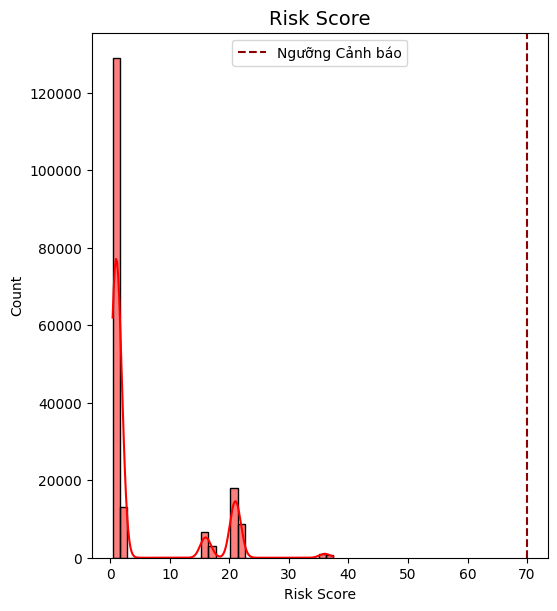

In [11]:
fig = plt.figure(figsize=(20, 15))
plt.subplot(2, 3, 1)
sns.histplot(data['risk_score'], bins=30, kde=True, color='red')
plt.title('Risk Score', fontsize=14)
plt.xlabel('Risk Score')
plt.axvline(70, color='darkred', linestyle='--', label='Ngưỡng Cảnh báo')
plt.legend()


- Phần lớn đơn hàng có mức rủi ro rất thấp, tập trung chủ yếu ở vùng 0–20 điểm.

- Hầu như không có đơn hàng vượt quá 40 điểm, cho thấy hệ thống vận hành ổn định và ít rủi ro nghiêm trọng.

- Ngưỡng cảnh báo 70 hiện nằm khá xa vùng dữ liệu thực → cần xem xét giảm ngưỡng cảnh báo (ví dụ còn 40–50) để phát hiện sớm các đơn bất thường.

- Một số cụm nhỏ quanh 10–25 điểm có thể là nhóm đơn hàng cần theo dõi (rủi ro tiềm ẩn, thường do chậm giao hoặc thanh toán tiền mặt).

### **2. Risk rate order by payment method**

Text(0.5, 0, 'Risk Score')

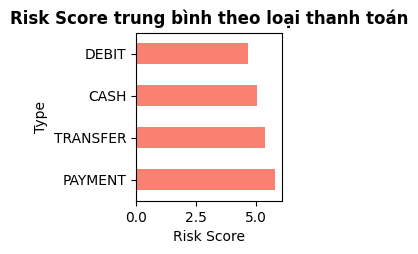

In [12]:
plt.subplot(2, 3, 3)
payment_risk = data.groupby('Type')['risk_score'].mean().sort_values(ascending=False)
payment_risk.plot(kind='barh', color='salmon')
plt.title('Risk Score trung bình theo loại thanh toán', fontweight='bold')
plt.xlabel('Risk Score')

- PAYMENT có Risk Score trung bình cao nhất (≈ 6 điểm), cho thấy hình thức thanh toán này tiềm ẩn rủi ro cao nhất trong các loại.

- TRANSFER (chuyển khoản) có mức rủi ro chỉ thấp hơn chút, vẫn ở nhóm cao.

- CASH (tiền mặt) có mức rủi ro trung bình thấp hơn, nhưng vẫn đáng chú ý.

- DEBIT (thẻ ghi nợ) có Risk Score thấp nhất, tức là phương thức này an toàn hơn so với các hình thức còn lại.

=> Phương thức PAYMENT và TRANSFER có điểm rủi ro trung bình cao nhất, cho thấy hai hình thức này tiềm ẩn nhiều nguy cơ gian lận hơn. Trong khi đó, DEBIT và CASH có mức rủi ro thấp hơn, thể hiện tính an toàn cao hơn. Do đó, doanh nghiệp nên tăng cường kiểm soát và xác thực giao dịch đối với các phương thức thanh toán trực tuyến.

### **3. Relationship between discount and profit**

Text(0, 0.5, 'Lợi nhuận/đơn')

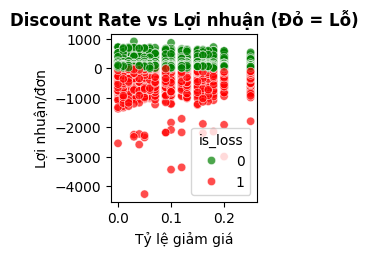

In [13]:
plt.subplot(2, 3, 4)
sns.scatterplot(data=data, x='Order_Item_Discount_Rate', y='Order_Profit_Per_Order',
                hue='is_loss', palette={0: 'green', 1: 'red'}, alpha=0.7)
plt.title('Discount Rate vs Lợi nhuận (Đỏ = Lỗ)', fontweight='bold')
plt.xlabel('Tỷ lệ giảm giá')
plt.ylabel('Lợi nhuận/đơn')

- Khi tỷ lệ giảm giá (Discount Rate) tăng, số lượng điểm màu đỏ (lỗ) tăng rõ rệt.

- Ở mức giảm giá thấp (dưới 5%), phần lớn đơn hàng vẫn có lợi nhuận (điểm xanh).

- Từ khoảng >10% discount trở lên, nhiều đơn hàng bắt đầu chuyển sang lỗ nặng, thậm chí lỗ hơn -3000$/đơn.

=> Tỷ lệ giảm giá cao dẫn đến nguy cơ lỗ đơn hàng tăng mạnh, cho thấy chính sách khuyến mãi đang ảnh hưởng tiêu cực đến lợi nhuận. Doanh nghiệp nên giới hạn mức giảm giá tối ưu (dưới ~10%) để cân bằng giữa doanh số và lợi nhuận.

### **4. High-end products holes**

Text(0.5, 0, 'Tổng lỗ ($)')

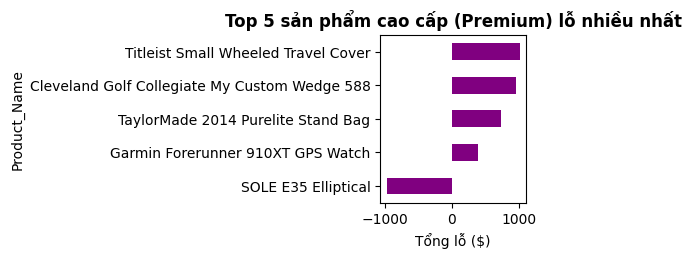

In [14]:
plt.subplot(2, 3, 6)
premium_loss = data[data['is_premium_product']==1].groupby('Product_Name')['Order_Profit_Per_Order'].sum().sort_values().head(5)
premium_loss.plot(kind='barh', color='purple')
plt.title('Top 5 sản phẩm cao cấp (Premium) lỗ nhiều nhất', fontweight='bold')
plt.xlabel('Tổng lỗ ($)')

- Hai sản phẩm lỗ nặng nhất: Titleist Small Wheeled Travel Cover (~$1,000) và Cleveland Golf Collegiate My Custom Wedge 588 (~$950).

- TaylorMade 2014 Purelite Stand Bag lỗ vừa phải (~$600–700), Garmin Forerunner 910XT GPS Watch lỗ nhỏ (~$200–300).

- SOLE E35 Elliptical có giá trị âm (khoảng -$800) — tức không lỗ mà có lãi so với nhóm này.

=> Các sản phẩm thể thao và golf cao cấp đang thua lỗ, đặc biệt là thiết bị tập luyện (SOLE E35), cho thấy chi phí cao nhưng doanh thu không tương xứng — cần xem lại định giá hoặc chiến lược bán hàng cho nhóm hàng này.

### **5. Correlation**

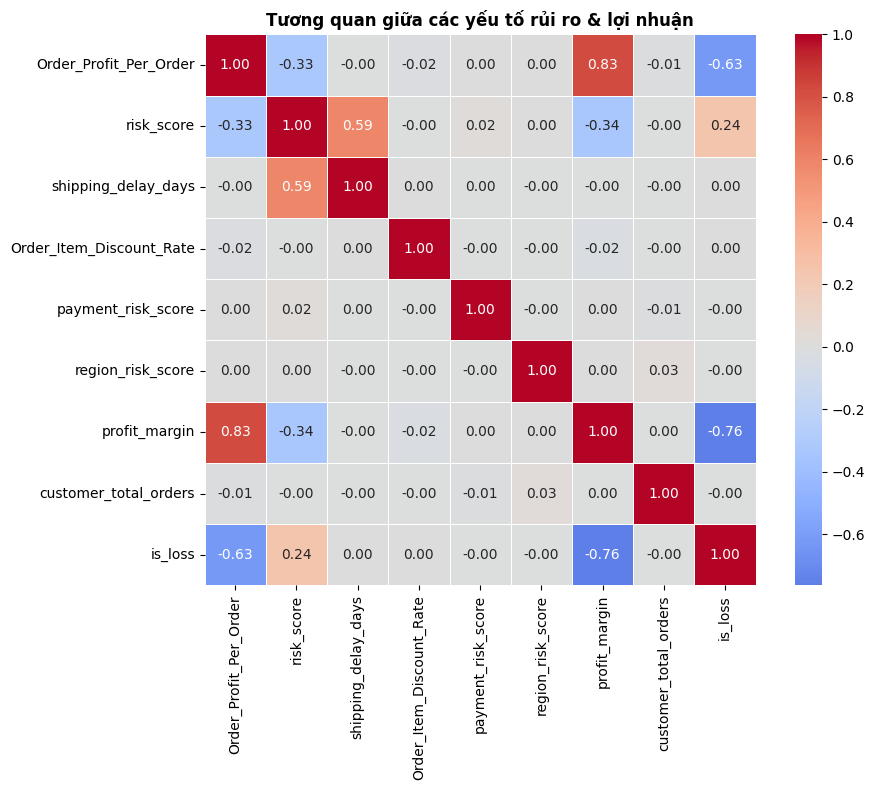

In [15]:
corr_cols = ['Order_Profit_Per_Order', 'risk_score', 'shipping_delay_days',
             'Order_Item_Discount_Rate', 'payment_risk_score', 'region_risk_score',
             'profit_margin', 'customer_total_orders', 'is_loss']

corr = data[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=.5)
plt.title('Tương quan giữa các yếu tố rủi ro & lợi nhuận', fontweight='bold')
plt.tight_layout()

- Profit margin và Order_Profit_Per_Order tương quan dương mạnh (r=0.83) → biên lợi nhuận là yếu tố quyết định lợi nhuận.


- Profit margin và is_loss tương quan âm mạnh (r=-0.76) → biên lợi nhuận thấp gần như chắc chắn dẫn đến lỗ.


- Risk_score có tương quan âm với lợi nhuận (r=-0.33) và dương với lỗ (r=0.24) → rủi ro cao làm giảm hiệu quả.


- Shipping_delay_days liên hệ dương với risk_score (r=0.59) → giao hàng chậm làm tăng rủi ro.


- Customer_total_orders tương quan âm với lỗ (r=-0.76) → khách hàng mua nhiều lần có khả năng sinh lợi cao hơn.


=> Tập trung giảm rủi ro (đặc biệt là giao hàng chậm) và tăng giữ chân khách hàng trung thành sẽ giúp giảm lỗ và cải thiện lợi nhuận.

# **MODELING**

## **Profit Analysis**

In [16]:
profit_features = [
    'Order_Item_Discount_Rate',
    'discount_impact', 
    'Sales',
    'Order_Item_Quantity',
    'Product_Price',
    'shipping_delay_days',  
    'is_loss',              
    'customer_total_orders', 
    'is_new_customer',
    'Category_Name',
    'is_premium_product',    
    'product_avg_profit_margin',
    'Market',
    'Order_Region',
    'order_hour',
    'is_weekend',
    'profit_7d_rolling' 
]

y = data['Order_Profit_Per_Order']

X = pd.get_dummies(data[profit_features], drop_first=True)

print(f"✅ Đã chọn {len(profit_features)} features → {X.shape[1]} sau encoding")
print(f"✅ Số mẫu: {len(X)}")

✅ Đã chọn 17 features → 89 sau encoding
✅ Số mẫu: 180519


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    eval_metric='mae'
)

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
print(f"CV MAE: ${-cv_scores.mean():,.0f} ± ${cv_scores.std():,.0f}")

# Train final model
model.fit(X_train, y_train)

CV MAE: $31 ± $0


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [18]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nFINAL MODEL PERFORMANCE:")
print(f"MAE  (sai số trung bình): ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"R²   : {r2:.4f}")


FINAL MODEL PERFORMANCE:
MAE  (sai số trung bình): $31
RMSE : $61
R²   : 0.6592


In [19]:
joblib.dump(model, "profit_model.pkl")
joblib.dump(X.columns, "profit_columns.pkl")  
print("ĐÃ LƯU: profit_model.pkl")


ĐÃ LƯU: profit_model.pkl


In [20]:
# Hàm dự đoán đơn hàng mới
def predict_profit_new_order(order_dict):
    input_df = pd.DataFrame([order_dict])
    input_encoded = pd.get_dummies(input_df, drop_first=True)
    input_final = input_encoded.reindex(columns=X.columns, fill_value=0)
    profit = model.predict(input_final)[0]
    return round(profit, 2)

# === TEST VỚI ĐƠN HÀNG MỚI ===
new_order = {
    'Order_Item_Quantity': 1,
    'Order_Item_Discount_Rate': 0.25,
    'Sales': 2000,
    'Product_Price': 2000,
    'shipping_delay_days': 6,
    'is_loss': 1,
    'customer_total_orders': 1,
    'is_new_customer': 1,
    'is_premium_product': 1,
    'product_avg_profit_margin': 0.1,
    'order_hour': 2,
    'is_weekend': 0,
    'profit_7d_rolling': 500,
    'Market': 'LATAM',
    'Order_Region': 'Central America',
    'Category_Name': 'Golf'
}

predicted = predict_profit_new_order(new_order)
print(f"\nDỰ ĐOÁN LỢI NHUẬN: ${predicted:,.0f}")


DỰ ĐOÁN LỢI NHUẬN: $-934


## **Risk Analysis**

In [21]:
def define_risk(row):
    # High Risk: Hủy, gian lận, hoặc lỗ nặng
    if row['Order_Status'] in ['SUSPECTED_FRAUD', 'CANCELED']:
        return 'High Risk'
    if row['Order_Profit_Per_Order'] < -100:
        return 'High Risk'
    
    # Medium Risk: Chậm giao, pending, lỗ nhẹ
    if row['Order_Status'] in ['PENDING', 'ON_HOLD', 'PENDING_PAYMENT']:
        return 'Medium Risk'
    if row['shipping_delay_days'] > 5:
        return 'Medium Risk'
    if row['Order_Profit_Per_Order'] < 0:
        return 'Medium Risk'
    
    # Low Risk
    return 'Low Risk'

data['risk_level'] = data.apply(define_risk, axis=1)
print(data['risk_level'].value_counts())

risk_level
Medium Risk    91084
Low Risk       70664
High Risk      18771
Name: count, dtype: int64


In [22]:
risk_features = [
    'Type',
    'Order_Status',
    'Order_Item_Discount_Rate',
    'shipping_delay_days',
    'customer_total_orders',
    'is_new_customer',
    'Order_Region',
    'Market',
    'Category_Name',
    'is_premium_product',
    'order_hour',
    'is_weekend'
]

X_risk = pd.get_dummies(data[risk_features], drop_first=True)
y_risk = data['risk_level']

print(f"Features: {X_risk.shape[1]}, Samples: {len(X_risk)}")

Features: 93, Samples: 180519


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_risk, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)

model_risk = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    class_weight='balanced',  # xử lý imbalance
    random_state=42,
    n_jobs=-1
)

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_risk, X_train, y_train, cv=cv, scoring='f1_macro')

print(f"CV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV F1-macro: 0.7966 ± 0.0059


In [24]:
model_risk.fit(X_train, y_train)
y_pred = model_risk.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   High Risk       0.99      0.41      0.58      3754
    Low Risk       0.82      1.00      0.90     14133
 Medium Risk       0.93      0.88      0.91     18217

    accuracy                           0.88     36104
   macro avg       0.91      0.76      0.80     36104
weighted avg       0.89      0.88      0.87     36104



In [25]:
def predict_risk_hybrid(order_dict):
    # RULE TRƯỚC
    if order_dict.get('Type') in ['PAYMENT', 'TRANSFER']:
        if order_dict.get('Order_Item_Discount_Rate', 0) > 0.10:
            return 'High Risk', 'RULE: PAYMENT/TRANSFER + Discount >10%'
    
    if order_dict.get('shipping_delay_days', 0) > 5:
        if order_dict.get('is_new_customer', 0) == 1:
            return 'High Risk', 'RULE: Giao chậm + khách mới'
    
    if 'Golf' in str(order_dict.get('Category_Name', '')):
        if order_dict.get('Order_Item_Discount_Rate', 0) > 0.08:
            return 'High Risk', 'RULE: Golf + giảm giá'
    
    # DÙNG MODEL
    df_in = pd.DataFrame([order_dict])
    df_enc = pd.get_dummies(df_in, drop_first=True)
    df_final = df_enc.reindex(columns=X_risk.columns, fill_value=0)
    pred = model_risk.predict(df_final)[0]
    prob = model_risk.predict_proba(df_final)[0]
    return pred, f"MODEL: {prob.max():.1%} confidence"

In [26]:
joblib.dump(model_risk, "risk_model_final.pkl")
joblib.dump(X_risk.columns.tolist(), "risk_columns.pkl")

['risk_columns.pkl']

In [27]:
def predict_risk_new(order_dict):
    return predict_risk_hybrid(order_dict)

# TEST
new_order = {
    'Type': 'PAYMENT',
    'Order_Item_Discount_Rate': 0.15,
    'shipping_delay_days': 6,
    'is_new_customer': 1,
    'Category_Name': 'Golf'
}
risk, reason = predict_risk_new(new_order)
print(f"RỦI RO: {risk} → {reason}")

RỦI RO: High Risk → RULE: PAYMENT/TRANSFER + Discount >10%
